# 12.2 — Backtesting: Kupiec, Christoffersen

Un modelo de VaR se **backtestea** contando violaciones (pérdida realizada > VaR
pronosticado) sobre una ventana histórica. El **test de Kupiec** (POF, proporción de
fallas) chequea sólo la TASA total de violaciones. El **test de Christoffersen** además
chequea su **independencia** en el tiempo — un modelo puede tener la tasa total correcta
en promedio y aun así fallar, si las violaciones se agrupan en clusters (el caso donde
Kupiec solo no detecta el problema).

## 0. Configuración

In [1]:
import numpy as np
from scipy.stats import chi2, norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

alpha_conf = 0.99
z_alpha = norm.ppf(alpha_conf)

## 1. Test de Kupiec (POF)

Bajo $H_0$ (modelo correcto), el número de violaciones $x$ en $n$ días sigue
Binomial$(n,1-\alpha)$. Razón de verosimilitud, asintóticamente $\chi^2(1)$:
$$LR_{POF} = -2\ln\left[\frac{(1-p)^{n-x}p^x}{(1-\hat p)^{n-x}\hat p^x}\right],\quad p=1-\alpha,\ \hat p=x/n$$

In [2]:
def kupiec_test(n, x, alpha_conf, sig_level=0.05):
    p = 1.0 - alpha_conf
    if x == 0:
        LR = -2.0 * n * np.log(1.0 - p)
    elif x == n:
        LR = -2.0 * n * np.log(p)
    else:
        LR = -2.0 * (n * np.log(1.0 - p) + x * np.log(p / (1.0 - p))
                      - x * np.log(x / n) - (n - x) * np.log(1.0 - x / n))
    pval = 1.0 - chi2.cdf(LR, df=1)
    return LR, pval, pval < sig_level

### Demo 1 — modelo correcto: tasa de rechazo empírica vs nivel nominal del test

Si el modelo de VaR es correcto (aquí, calibrado con la volatilidad verdadera), Kupiec debería rechazarlo solo por azar — al nivel de significancia del test (5%), sin importar cuántas veces se repita el backtest. Repetimos el experimento completo (simular 1000 días, contar violaciones, correr Kupiec) 500 veces y medimos qué fracción de esas repeticiones rechaza — el mismo criterio de "tasa de cobertura" usado para validar intervalos de confianza en 04.1.

In [3]:
sigma_true = 0.20
n_days = 1000
n_reps = 500
reject_correct = 0
for _ in range(n_reps):
    r = rng.normal(0.0, sigma_true, n_days)
    VaR_correct = z_alpha * sigma_true
    violations = (-r) > VaR_correct
    _, _, rej = kupiec_test(n_days, violations.sum(), alpha_conf)
    reject_correct += rej

rate_correct = reject_correct / n_reps
print(f"modelo correcto (VaR con sigma verdadera): tasa de rechazo de Kupiec = {rate_correct:.3f} "
      f"(nivel nominal del test: 5%)")

modelo correcto (VaR con sigma verdadera): tasa de rechazo de Kupiec = 0.056 (nivel nominal del test: 5%)


### Demo 2 — modelo mal calibrado (volatilidad subestimada)

Ahora el VaR se calcula con una volatilidad deliberadamente menor a la real — el modelo subestima el riesgo. Sobre las mismas 500 repeticiones, Kupiec debería rechazar casi siempre: las violaciones ocurrirán con una frecuencia mucho mayor a la que el modelo (con su VaR demasiado ajustado) predice.

In [4]:
sigma_model_bad = 0.15  # subestima sigma_true=0.20
reject_bad = 0
for _ in range(n_reps):
    r = rng.normal(0.0, sigma_true, n_days)
    VaR_bad = z_alpha * sigma_model_bad
    violations = (-r) > VaR_bad
    _, _, rej = kupiec_test(n_days, violations.sum(), alpha_conf)
    reject_bad += rej

rate_bad = reject_bad / n_reps
print(f"modelo mal calibrado (sigma subestimada): tasa de rechazo de Kupiec = {rate_bad:.3f} "
      f"(deberia ser >> 5%)")

modelo mal calibrado (sigma subestimada): tasa de rechazo de Kupiec = 1.000 (deberia ser >> 5%)


## 2. Test de Christoffersen: independencia de violaciones

Cadena de Markov de 2 estados (violación/no-violación); $LR_{ind}$ chequea si
$P(\text{violacion hoy}\mid\text{violacion ayer})$ difiere de
$P(\text{violacion hoy}\mid\text{no violacion ayer})$ — si el modelo es correcto, no
deberían diferir (las violaciones no deberían agruparse). Test conjunto (cobertura +
independencia): $LR_{cc}=LR_{POF}+LR_{ind}\sim\chi^2(2)$.

In [5]:
def christoffersen_independence(violations, sig_level=0.05):
    n = len(violations)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, n):
        prev, cur = violations[i - 1], violations[i]
        if not prev and not cur:
            n00 += 1
        elif not prev and cur:
            n01 += 1
        elif prev and not cur:
            n10 += 1
        else:
            n11 += 1

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    def safe_log(x):
        return np.log(x) if x > 0 else 0.0

    L0 = (n00 + n10) * safe_log(1 - pi) + (n01 + n11) * safe_log(pi)
    L1 = (n00 * safe_log(1 - pi01) + n01 * safe_log(pi01)
          + n10 * safe_log(1 - pi11) + n11 * safe_log(pi11))
    LR_ind = -2.0 * (L0 - L1)
    pval_ind = 1.0 - chi2.cdf(LR_ind, df=1)
    return LR_ind, pval_ind, pval_ind < sig_level

### Demo 3 — violaciones agrupadas con tasa TOTAL correcta: Kupiec no lo detecta, Christoffersen sí

Régimen de volatilidad que cambia (10% de los días con $\sigma$ alta, 90% con $\sigma$
baja) — el VaR se calibra con un nivel ÚNICO tal que la tasa de violación
INCONDICIONAL (mezclando ambos regímenes) sea exactamente 1%, así que Kupiec (que sólo
mira la tasa total) no tiene motivo para rechazar. Pero las violaciones se concentran
en el régimen de vol alta — Christoffersen debe detectarlo.

In [6]:
frac_high, sigma_high, sigma_low = 0.10, 0.60, 0.10


def unconditional_violation_rate(VaR):
    return (frac_high * (1 - norm.cdf(VaR / sigma_high))
            + (1 - frac_high) * (1 - norm.cdf(VaR / sigma_low)) - (1 - alpha_conf))


VaR_star = brentq(unconditional_violation_rate, 0.0, 5.0)
print(f"VaR* (calibrado para tasa incondicional exacta de {1-alpha_conf:.0%}): {VaR_star:.4f}")

reject_christoffersen_clustered = 0
reject_kupiec_clustered = 0
avg_violations_clustered = 0
for _ in range(n_reps):
    sigma_regime = np.where(np.arange(n_days) < int(frac_high * n_days), sigma_high, sigma_low)
    r = rng.normal(0.0, sigma_regime)
    violations = (-r) > VaR_star
    avg_violations_clustered += violations.sum()
    _, _, rej_ind = christoffersen_independence(violations)
    reject_christoffersen_clustered += rej_ind
    _, _, rej_kupiec = kupiec_test(n_days, violations.sum(), alpha_conf)
    reject_kupiec_clustered += rej_kupiec

rate_christoffersen_clustered = reject_christoffersen_clustered / n_reps
rate_kupiec_clustered = reject_kupiec_clustered / n_reps
print(f"\nviolaciones promedio: {avg_violations_clustered/n_reps:.1f} (esperado ~{(1-alpha_conf)*n_days:.0f})")
print(f"tasa de rechazo de Kupiec (tasa total correcta): {rate_kupiec_clustered:.3f} (~nominal 5%, esperado)")
print(f"tasa de rechazo de Christoffersen (independencia): {rate_christoffersen_clustered:.3f} "
      f"(debe ser >> 5% -- SI detecta el clustering)")

VaR* (calibrado para tasa incondicional exacta de 1%): 0.7689



violaciones promedio: 10.0 (esperado ~10)
tasa de rechazo de Kupiec (tasa total correcta): 0.034 (~nominal 5%, esperado)
tasa de rechazo de Christoffersen (independencia): 0.332 (debe ser >> 5% -- SI detecta el clustering)


### Demo 4 — mismas violaciones, pero NO agrupadas (régimen mezclado aleatoriamente)

Control de que Christoffersen no rechaza por rechazar: tomamos el mismo régimen de volatilidad de la Demo 3 (10% de días de vol alta, 90% de vol baja) pero mezclamos aleatoriamente el orden de los días — la tasa total de violaciones no cambia, pero ya no se agrupan en el tiempo. Christoffersen debería dejar de rechazar, confirmando que lo que detectaba en la Demo 3 era específicamente el clustering, no algún otro artefacto.

tasa de rechazo de Christoffersen (regimen mezclado, sin clustering): 0.022 (~nominal 5%, esperado)


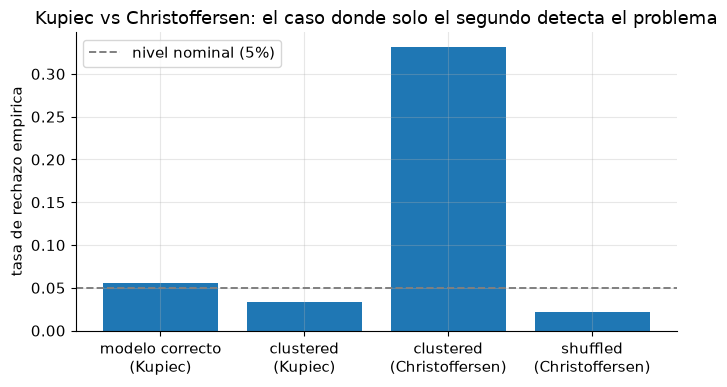

In [7]:
reject_christoffersen_shuffled = 0
for _ in range(n_reps):
    sigma_regime = np.where(np.arange(n_days) < int(frac_high * n_days), sigma_high, sigma_low)
    sigma_shuffled = rng.permutation(sigma_regime)
    r = rng.normal(0.0, sigma_shuffled)
    violations = (-r) > VaR_star
    _, _, rej_ind = christoffersen_independence(violations)
    reject_christoffersen_shuffled += rej_ind

rate_christoffersen_shuffled = reject_christoffersen_shuffled / n_reps
print(f"tasa de rechazo de Christoffersen (regimen mezclado, sin clustering): "
      f"{rate_christoffersen_shuffled:.3f} (~nominal 5%, esperado)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["modelo correcto\n(Kupiec)", "clustered\n(Kupiec)", "clustered\n(Christoffersen)",
        "shuffled\n(Christoffersen)"],
       [rate_correct, rate_kupiec_clustered, rate_christoffersen_clustered, rate_christoffersen_shuffled])
ax.axhline(0.05, color="gray", ls="--", label="nivel nominal (5%)")
ax.set_ylabel("tasa de rechazo empirica")
ax.set_title("Kupiec vs Christoffersen: el caso donde solo el segundo detecta el problema")
ax.legend(); fig.tight_layout(); plt.show()

## 3. Validación

Cuatro chequeos, uno por demo: (1) el modelo correcto rechaza a una tasa cercana al nivel nominal del test; (2) el modelo mal calibrado rechaza casi siempre; (3) el punto pedagógico central — con violaciones agrupadas pero tasa total correcta, Christoffersen rechaza y Kupiec no; (4) sin agrupamiento, Christoffersen deja de rechazar espuriamente.

In [8]:
check1 = 0.02 <= rate_correct <= 0.10
print(f"1. modelo correcto: tasa de rechazo de Kupiec dentro de una banda alrededor del 5% nominal: "
      f"{rate_correct:.3f} (<in [0.02,0.10]>? {check1})")

check2 = rate_bad > 0.5
print(f"2. modelo mal calibrado: tasa de rechazo de Kupiec sustancialmente mayor al nominal: "
      f"{rate_bad:.3f} (>0.5? {check2})")

check3 = rate_christoffersen_clustered > 0.20 and rate_kupiec_clustered <= 0.10
print(f"3. violaciones agrupadas (tasa correcta): Christoffersen SI rechaza "
      f"({rate_christoffersen_clustered:.3f}) mientras Kupiec no ({rate_kupiec_clustered:.3f}) -- "
      f"el punto pedagogico central: {check3}")

check4 = rate_christoffersen_shuffled <= 0.10
print(f"4. violaciones no agrupadas: Christoffersen no rechaza espuriamente: "
      f"{rate_christoffersen_shuffled:.3f} (<=0.10? {check4})")

assert check1
assert check2
assert check3
assert check4
print("\nValidacion completa: 4/4 dentro de tolerancia.")

1. modelo correcto: tasa de rechazo de Kupiec dentro de una banda alrededor del 5% nominal: 0.056 (<in [0.02,0.10]>? True)
2. modelo mal calibrado: tasa de rechazo de Kupiec sustancialmente mayor al nominal: 1.000 (>0.5? True)
3. violaciones agrupadas (tasa correcta): Christoffersen SI rechaza (0.332) mientras Kupiec no (0.034) -- el punto pedagogico central: True
4. violaciones no agrupadas: Christoffersen no rechaza espuriamente: 0.022 (<=0.10? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Kupiec, P. (1995). *Techniques for Verifying the Accuracy of Risk Measurement Models*.
  Journal of Derivatives, 3(2), 73-84.
- Christoffersen, P. (1998). *Evaluating Interval Forecasts*. International Economic
  Review, 39(4), 841-862.